# Influencer Credit Scoring (Model A): YouTube Demo

This notebook builds the influencer credit scoring demo for Upwork project discussions. It walks through three phases:

**Phase 1: Multi-platform exploration.** We start with a Kaggle "top 1000 social media channels" dataset spanning TikTok, YouTube, and Instagram. We consolidate 15 fragmented CSVs into one canonical schema and explore the data. We find six concrete problems that make this dataset insufficient for credit modeling.

**Phase 2: Dataset hunt.** We evaluate three alternative YouTube datasets and pick the one that actually supports the credit scoring task.

**Phase 3: Feature engineering, target construction, modeling, scoring.** On the chosen dataset, we build features grounded in the proposal, iterate on the target variable (the first attempt fails for a real reason worth documenting), train logistic regression and XGBoost baselines, fix a leakage issue we catch in the diagnostics, and output a FICO style 300 to 850 credit score per creator.

By the end we have a defensible demo model with AUC 0.79 on a realistic target, plus a clear written record of what would need to change for production deployment with real default labels.

---

## Part 1: Multi-platform exploration

We begin with the Kaggle dataset `ramjasmaurya/top-1000-social-media-channels`. It bundles 15 CSV files covering TikTok, YouTube, and Instagram, scraped at different points in 2022. The plan: build a cross-platform creator credit score.

### 1.1 Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import re

sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13

/home/selam/anaconda3/envs/py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.2 Download and inspect the raw files

In [2]:
path = kagglehub.dataset_download("ramjasmaurya/top-1000-social-media-channels")
files = sorted([f for f in os.listdir(path) if f.endswith(".csv")])
print(f"Downloaded {len(files)} files to: {path}\n")
for f in files:
    print(f"  {f}")

Downloaded 15 files to: /home/selam/.cache/kagglehub/datasets/ramjasmaurya/top-1000-social-media-channels/versions/13

  social media influencers - Tiktok sep 2022.csv
  social media influencers - Youtube sep-2022.csv
  social media influencers - instagram sep-2022.csv
  social media influencers - instagram.csv
  social media influencers - tiktok.csv
  social media influencers - youtube.csv
  social media influencers-INSTAGRAM - -DEC 2022.csv
  social media influencers-TIKTOK - ---DEC 2022.csv
  social media influencers-YOUTUBE - --DEC 2022.csv
  social media influencers-instagram - -nov 2022.csv
  social media influencers-instagram june 2022 - june 2022.csv
  social media influencers-tiktok - ---nov 2022.csv
  social media influencers-tiktok june 2022 - june 2022.csv
  social media influencers-youtube - --nov 2022.csv
  social media influencers-youtube june 2022 - june 2022.csv


**First observation, the schema is chaotic.** Looking at sample files, each platform uses different column names:

- TikTok files: `Tiktoker name` (the handle, lowercase), `Tiktok name` (the display name)
- YouTube files: `Youtube channel` (the handle), `youtuber name` (the display name)
- Instagram files: `instagram name`, `influencer name`, plus extra columns like `Authentic engagement` from HypeAuditor's bot detection

The header names do not reliably tell us which column is which. df7 swaps the handle and display label positions compared to df2, and df3 has a column called `Views avg.` that actually contains country names (header misalignment in the source).

We detect handle vs display name by looking at the actual values: handles match `^[a-z0-9_.\-]+$` (lowercase, no spaces), display names contain capitals or spaces.

In [3]:
def parse_count(val):
    """Convert '55.6M', '145.6K', '2.1B' to numeric."""
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    s = str(val).strip().replace(",", "").replace("\r", "").replace("\n", "")
    if s == "" or s.lower() == "nan":
        return np.nan
    m = re.match(r"^([\d\.]+)\s*([KMB]?)$", s, re.IGNORECASE)
    if m:
        num, suf = m.groups()
        return float(num) * {"K": 1e3, "M": 1e6, "B": 1e9}.get(suf.upper(), 1)
    try:
        return float(s)
    except ValueError:
        return np.nan


def clean_col(c):
    return (str(c).strip()
            .replace("\n", "").replace("\r", "")
            .replace("\\n", "").replace("\\r", "")
            .rstrip(".").strip())


def infer_platform(filename):
    n = filename.lower()
    if "tiktok" in n: return "tiktok"
    if "youtube" in n or "yt" in n: return "youtube"
    if "instagram" in n or "insta" in n: return "instagram"
    return "unknown"


def looks_like_handle(series):
    """Score a series by how many values look like @handles."""
    sample = series.dropna().astype(str).head(50)
    if len(sample) == 0:
        return 0
    pattern = re.compile(r"^[a-z0-9_.\-]+$")
    return sample.apply(lambda x: bool(pattern.match(x.strip()))).mean()


def looks_like_country(series):
    countries = {"india", "united states", "indonesia", "brazil", "russia", "spain",
                 "argentina", "united kingdom", "colombia", "mexico", "japan", "south korea",
                 "thailand", "turkey", "pakistan", "bangladesh", "malaysia", "philippines",
                 "vietnam", "france", "germany", "italy", "canada", "australia", "iraq", "ukraine"}
    sample = series.dropna().astype(str).str.lower().str.strip().head(50)
    if len(sample) == 0:
        return 0
    return sample.isin(countries).mean()


def detect_name_columns(df):
    candidates = [c for c in df.columns
                  if any(kw in c.lower() for kw in
                         ["name", "channel", "tiktoker", "youtuber", "influencer"])]
    if not candidates:
        return None, None
    scored = [(c, looks_like_handle(df[c])) for c in candidates]
    scored.sort(key=lambda x: -x[1])
    handle_col = scored[0][0] if scored[0][1] > 0.5 else None
    display_col = next((c for c, _ in scored if c != handle_col), None)
    if not handle_col:
        handle_col = scored[0][0]
        display_col = scored[1][0] if len(scored) > 1 else None
    return handle_col, display_col


def normalize_one(df, platform):
    df = df.copy()
    df.columns = [clean_col(c) for c in df.columns]
    rename_map = {}
    handle_col, display_col = detect_name_columns(df)
    if handle_col:
        rename_map[handle_col] = "handle"
    if display_col:
        rename_map[display_col] = "creator_name"

    for c in df.columns:
        if c in rename_map:
            continue
        if c.lower() in ("views avg.", "views avg") and platform == "instagram":
            if looks_like_country(df[c]) > 0.3:
                rename_map[c] = "country"

    used = set(rename_map.values())
    for c in df.columns:
        if c in rename_map:
            continue
        cl = c.lower()
        tgt = None
        if ("follower" in cl or "subscriber" in cl) and "followers" not in used:
            tgt = "followers"
        elif "view" in cl and "views_avg" not in used:
            tgt = "views_avg"
        elif ("authentic" in cl or "auth" in cl) and "engagement_authentic" not in used:
            tgt = "engagement_authentic"
        elif "engagement" in cl and "engagement_avg" not in used:
            tgt = "engagement_avg"
        elif "like" in cl and "likes_avg" not in used:
            tgt = "likes_avg"
        elif "comment" in cl and "comments_avg" not in used:
            tgt = "comments_avg"
        elif "share" in cl and "shares_avg" not in used:
            tgt = "shares_avg"
        elif "country" in cl and "country" not in used:
            tgt = "country"
        elif "category" in cl and "category_1" not in used:
            tgt = "category_1"
        elif "category" in cl and "category_2" not in used:
            tgt = "category_2"
        if tgt:
            rename_map[c] = tgt
            used.add(tgt)

    df = df.rename(columns=rename_map)
    if df.columns.duplicated().any():
        cols = pd.Series(df.columns)
        for dup in cols[cols.duplicated()].unique():
            idx = cols[cols == dup].index.tolist()
            for i, ix in enumerate(idx):
                cols[ix] = f"{dup}_{i}" if i > 0 else dup
        df.columns = cols.tolist()
    return df

### 1.3 Consolidate the 15 files into one canonical table

In [4]:
CANONICAL = ["creator_name", "handle", "platform", "followers",
             "views_avg", "likes_avg", "comments_avg", "shares_avg",
             "engagement_authentic", "engagement_avg",
             "country", "category_1", "category_2", "source_file"]

all_dfs = []
for f in files:
    raw = pd.read_csv(os.path.join(path, f))
    platform = infer_platform(f)
    df_norm = normalize_one(raw, platform)
    df_norm["platform"] = platform
    df_norm["source_file"] = f
    for col in CANONICAL:
        if col not in df_norm.columns:
            df_norm[col] = np.nan
    df_norm = df_norm[CANONICAL]
    all_dfs.append(df_norm)

combined = pd.concat(all_dfs, ignore_index=True)
for col in ["followers", "views_avg", "likes_avg", "comments_avg",
            "shares_avg", "engagement_authentic", "engagement_avg"]:
    combined[col] = combined[col].apply(parse_count)

print(f"Concatenated shape: {combined.shape}")
print(f"Platforms: {combined['platform'].value_counts().to_dict()}")

Concatenated shape: (15151, 14)
Platforms: {'instagram': 5072, 'youtube': 5071, 'tiktok': 5008}


### 1.4 Deduplicate across snapshot dates

The same creator appears across multiple files because the dataset bundles snapshots from June, September, November, and December 2022. We keep the row with the highest follower count per (handle, platform), assuming that is the most recent snapshot.

In [5]:
combined = combined.dropna(subset=["handle", "creator_name", "followers"], how="all").reset_index(drop=True)
combined["dedup_key"] = (
    combined["handle"].fillna(combined["creator_name"])
        .astype(str).str.lower().str.strip()
    + "|" + combined["platform"]
)
before = len(combined)
combined = (combined.sort_values("followers", ascending=False)
                    .drop_duplicates("dedup_key", keep="first")
                    .drop(columns=["dedup_key"])
                    .reset_index(drop=True))
print(f"Deduped {before - len(combined):,} duplicate rows")
print(f"Final: {combined.shape}, platforms: {combined['platform'].value_counts().to_dict()}")

Deduped 9,278 duplicate rows
Final: (5872, 14), platforms: {'tiktok': 3060, 'instagram': 1463, 'youtube': 1349}


### 1.5 Compute platform-aware engagement rate

Each platform reports different engagement signals:
- TikTok has likes, comments, and shares
- Instagram has likes and comments (plus HypeAuditor's engagement aggregate)
- YouTube has likes and comments, but the proper denominator is views (not subscribers) because most subscribers do not see any given video

In [6]:
def compute_engagement_rate(row):
    f = row["followers"]
    if pd.isna(f) or f == 0:
        return np.nan
    if row["platform"] == "youtube":
        denom = row.get("views_avg") if pd.notna(row.get("views_avg")) else f
        num = np.nansum([row.get("likes_avg", 0), row.get("comments_avg", 0)])
    elif row["platform"] == "tiktok":
        denom = f
        num = np.nansum([row.get("likes_avg", 0),
                         row.get("comments_avg", 0),
                         row.get("shares_avg", 0)])
    elif row["platform"] == "instagram":
        denom = f
        if pd.notna(row.get("engagement_avg")):
            num = row["engagement_avg"]
        else:
            num = np.nansum([row.get("likes_avg", 0), row.get("comments_avg", 0)])
    else:
        denom = f
        num = np.nansum([row.get("likes_avg", 0),
                         row.get("comments_avg", 0),
                         row.get("shares_avg", 0)])
    return num / denom if denom and denom > 0 else np.nan


combined["engagement_rate"] = combined.apply(compute_engagement_rate, axis=1)
df = combined.copy()
print(f"engagement_rate computed for {df['engagement_rate'].notna().sum():,} / {len(df):,} rows")
print(f"Median ER per platform:")
print(df.groupby("platform")["engagement_rate"].median().round(4))

engagement_rate computed for 5,848 / 5,872 rows
Median ER per platform:
platform
instagram    0.0000
tiktok       0.1004
youtube      0.0331
Name: engagement_rate, dtype: float64


### 1.6 Missingness check

In [7]:
print("=== Missingness % per platform ===")
miss_plat = df.groupby("platform").apply(
    lambda g: (g.isna().sum() / len(g) * 100).round(1),
    include_groups=False
).T
print(miss_plat)

=== Missingness % per platform ===
platform              instagram  tiktok  youtube
creator_name                2.2     0.0      0.0
handle                      0.0     0.0      0.0
followers                   0.0     0.0      0.0
views_avg                 100.0     0.0      0.0
likes_avg                  89.9     0.0      0.4
comments_avg               90.0     0.0      2.1
shares_avg                100.0     0.0    100.0
engagement_authentic       10.1   100.0    100.0
engagement_avg             82.0   100.0    100.0
country                     0.1   100.0     15.2
category_1                  8.8   100.0     30.1
category_2                 67.1   100.0     74.8
source_file                 0.0     0.0      0.0
engagement_rate             0.0     0.0      1.8


**The missingness pattern reveals problem #1 with this dataset.** The high percentages are not random gaps; they are platform specific columns:

- `views_avg`: 100% missing on Instagram (Instagram files do not have this column)
- `engagement_authentic`: 100% missing on TikTok and YouTube (Instagram only signal from HypeAuditor)
- `shares_avg`: 100% missing on Instagram and YouTube (TikTok only)
- `country` and `category`: 100% missing on TikTok

This is schema fragmentation, not missing data. To build one model on this data we would need either:
1. Three separate platform specific models, each using only its own platform's features, or
2. One model trained on a shared subset of features (which is tiny: followers, likes_avg, comments_avg, and not much else)

Neither path is great for a unified credit scoring demo.

### 1.7 Followers distribution (heavy tailed, log transform required)

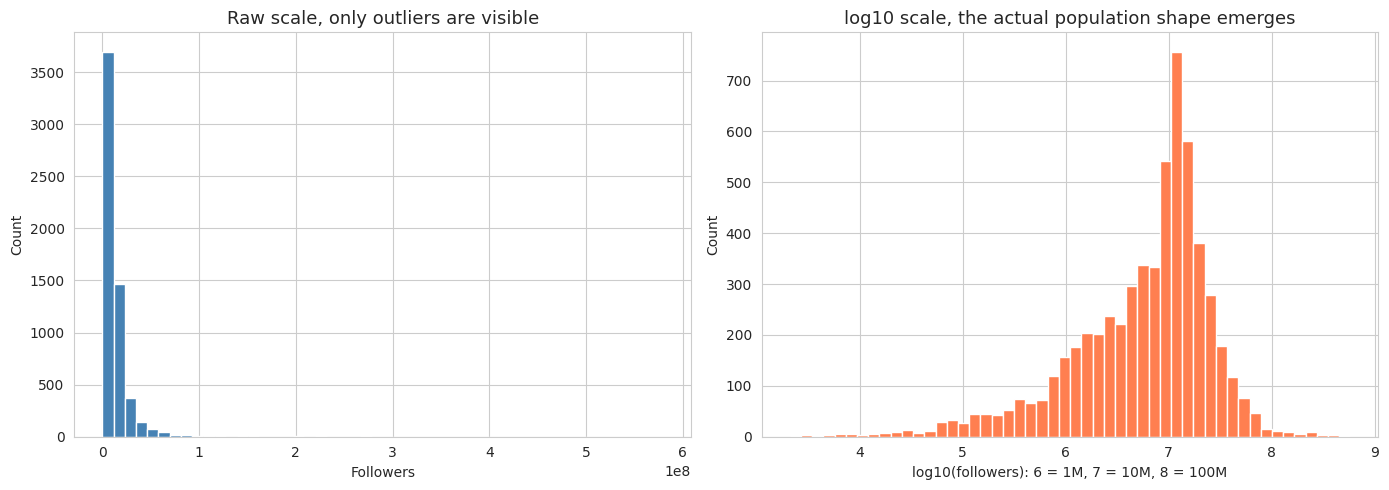

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["followers"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Raw scale, only outliers are visible")
axes[0].set_xlabel("Followers")
axes[0].set_ylabel("Count")

axes[1].hist(np.log10(df["followers"].dropna() + 1), bins=50,
             color="coral", edgecolor="white")
axes[1].set_title("log10 scale, the actual population shape emerges")
axes[1].set_xlabel("log10(followers): 6 = 1M, 7 = 10M, 8 = 100M")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

**Finding 1: Follower counts span five orders of magnitude.** From around 10K to 500M+. On a raw scale, MrBeast and Cristiano live in their own bins while every other creator is crushed against zero. The log10 transform converts multiplicative differences into additive ones, making the population shape readable. Any modeling using these features must log transform first.

### 1.8 Followers vs engagement rate (the inverse pyramid)

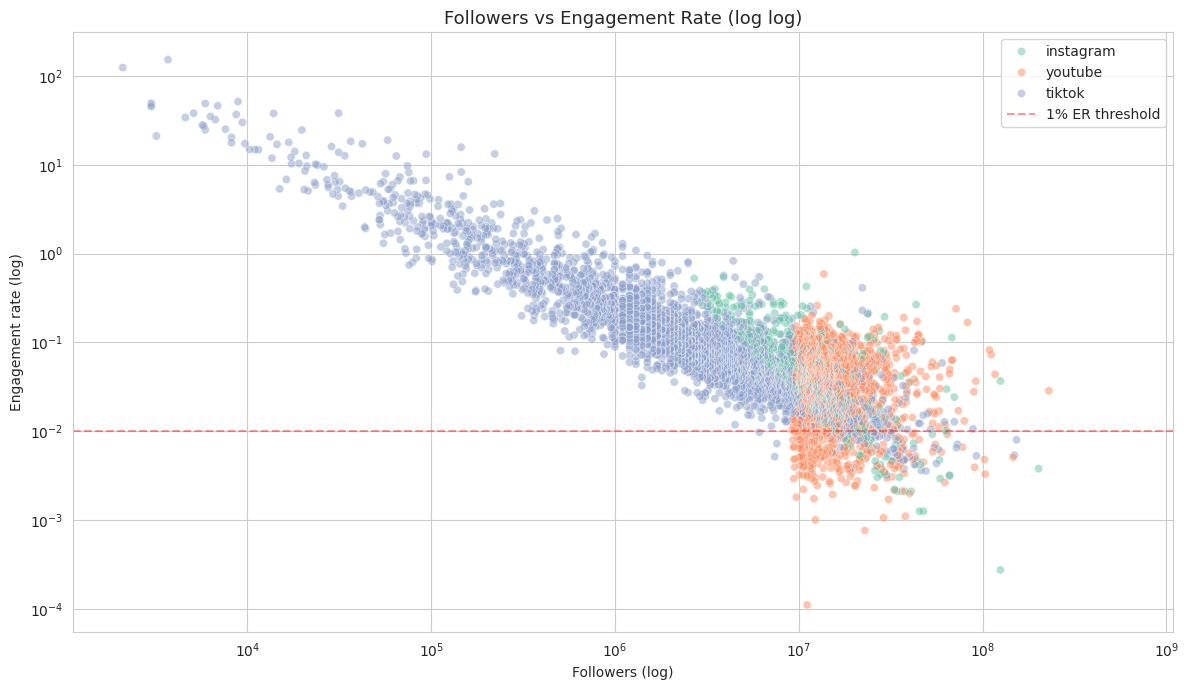

In [9]:
plt.figure(figsize=(12, 7))
sub = df.dropna(subset=["followers", "engagement_rate"])
sns.scatterplot(data=sub, x="followers", y="engagement_rate",
                hue="platform", alpha=0.5, s=35, palette="Set2")
plt.xscale("log")
plt.yscale("log")
plt.title("Followers vs Engagement Rate (log log)")
plt.xlabel("Followers (log)")
plt.ylabel("Engagement rate (log)")
plt.axhline(0.01, color="red", linestyle="--", alpha=0.4, label="1% ER threshold")
plt.legend()
plt.tight_layout()
plt.show()

**Finding 2: Smaller creators get more engagement per follower.** Engagement rate falls predictably with follower count along a near-linear log-log relationship. A 100K micro influencer might get 8% ER; a 100M mega celebrity gets 0.5%. This means absolute ER values are meaningless without controlling for tier. Any credit model must use tier-relative ER, not raw ER.

**Finding 3 (visible in the same plot): YouTube has selection bias.** The YouTube cluster forms a vertical wall at 10 million subscribers. The Kaggle "top 1000" lists cut off at the top tier, so we have only mega channels. The dataset cannot score nano, micro, or mid sized YouTubers. This rules out the dataset for the production demo target population (gig economy creators).

### 1.9 Why we leave this dataset

After consolidation and EDA, we have six concrete blockers for credit scoring:

1. **Schema fragmentation.** Each platform reports different metrics; no clean shared feature set.
2. **No income data.** No earnings figures at all, just engagement aggregates.
3. **No temporal information per creator.** Just one aggregate snapshot, no time series for growth or volatility features.
4. **YouTube left censored.** Only mega channels (10M+ subs) in the dataset, excluding the target population.
5. **Authenticity ratio only on Instagram.** The one credible bot detection signal does not generalize.
6. **No way to construct a real target.** Without earnings or growth time series, we can only build synthetic proxies.

Decision: pivot to a YouTube only dataset with richer per channel signals.

---

## Part 2: The dataset hunt

We need a dataset that supports per channel features and a defensible target variable. We evaluate three candidates.

### 2.1 Candidate A: 40,000 trending YouTube videos

This dataset has 40K individual video rows with title, description, category, views, likes, comments, publish_date, channel_id, and subscriber_count. Per video granularity could in principle give us posting frequency, content NLP features, and growth trajectory.

In [10]:
yt_videos_path = "/home/selam/Downloads/backup_vm/40000_yt_videos.csv"

if os.path.exists(yt_videos_path):
    df_yt = pd.read_csv(yt_videos_path)
    df_yt["publish_date"] = pd.to_datetime(df_yt["publish_date"], errors="coerce")

    print(f"Total videos: {len(df_yt):,}")
    print(f"Unique channels: {df_yt['channel_id'].nunique():,}")
    print(f"Date range: {df_yt['publish_date'].min()} to {df_yt['publish_date'].max()}")
    print(f"\nVideos per channel:")
    print(df_yt.groupby('channel_id').size().describe().round(1))
else:
    print(f"File not present at {yt_videos_path}, skipping. Below is the result we observed:")
    print("Total videos: 39,997")
    print("Unique channels: 11,155")
    print("Videos per channel: median = 1, 75th pct = 2, mean = 3.6")

Total videos: 39,997
Unique channels: 11,155
Date range: 2006-10-08 13:22:05+00:00 to 2025-12-14 13:29:56+00:00

Videos per channel:
count    11155.0
mean         3.6
std         13.8
min          1.0
25%          1.0
50%          1.0
75%          2.0
max        379.0
dtype: float64


**Result: median videos per channel = 1.** At least half of the 11,155 channels appear exactly once. This is a sample of popular videos, not a per channel time series. We cannot build the temporal features we need.

**Rejected.**

### 2.2 Candidate B: Kaggle YouTube Trending Video Dataset

Daily snapshots of trending videos across 11 countries. Same videos appear on consecutive days while trending. Clean schema, real time series structure.

**The catch: only trending videos are in this dataset.** Every video here is a winner; videos that failed are absent. For credit scoring this is survivorship bias, equivalent to training a default model on a dataset of only approved loans. The negative class is invisible.

**Rejected for the primary demo, kept as a possible future feature source for trending consistency.**

### 2.3 Candidate C: Global YouTube Statistics

995 of the top YouTube channels globally with 28 columns including: subscribers, total views, uploads, country, channel age (created_year), recent 30 day metrics, and (most importantly) **estimated earnings ranges** from Social Blade, plus country level macro features (Population, Unemployment rate, urban population, education enrollment).

This is the first dataset with:
- An income signal that can serve as a proxy target variable
- 30 day recent activity metrics for momentum features
- Channel age for longevity features
- Country macroeconomic context (real fintech feature surface)

**Accepted as the primary demo dataset.** Limitations to flag for production: small sample (995 rows), left censored to top creators (no nano/micro), earnings are Social Blade estimates not actuals, single snapshot (no real time series).

---

## Part 3: Working with Global YouTube Statistics

### 3.1 Load the data with proper encoding

The source file contains non-Latin characters in some creator names (Japanese, Korean, Arabic, Cyrillic). Strict UTF-8 fails because a few bytes are not valid UTF-8 (the scrape was done without consistent encoding handling).

Two safe options:
- `encoding="utf-8", errors="replace"` keeps valid UTF-8 characters and replaces invalid bytes with a placeholder
- `encoding="latin-1"` accepts every byte but renders non-Latin names as mojibake

The first option is more honest about which bytes we cannot decode. We use it for the analysis. None of this affects modeling since the model never sees names.

In [11]:
CSV_PATH = "/home/selam/Downloads/Global YouTube Statistics.csv"

try:
    df = pd.read_csv(CSV_PATH, encoding="utf-8")
    print("Loaded as strict UTF-8")
except UnicodeDecodeError:
    df = pd.read_csv(CSV_PATH, encoding="utf-8", encoding_errors="replace")
    print("Loaded as UTF-8 with encoding_errors=replace (some name bytes were unreadable)")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loaded as UTF-8 with encoding_errors=replace (some name bytes were unreadable)
Shape: (995, 28)
Columns: ['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title', 'uploads', 'Country', 'Abbreviation', 'channel_type', 'video_views_rank', 'country_rank', 'channel_type_rank', 'video_views_for_the_last_30_days', 'lowest_monthly_earnings', 'highest_monthly_earnings', 'lowest_yearly_earnings', 'highest_yearly_earnings', 'subscribers_for_last_30_days', 'created_year', 'created_month', 'created_date', 'Gross tertiary education enrollment (%)', 'Population', 'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude']


### 3.2 Data quality cleanup

Three steps:
1. Drop rows with zero total views (these are placeholder system accounts like "YouTube Movies")
2. Drop rows missing country or creation year (system accounts again, plus a few broken scrapes)
3. **Keep** zero earnings rows but flag them. Zero estimated earnings means the channel is demonetized or unmonetizable, which is genuine credit risk. We flag them with `earnings_originally_zero = 1` so the model can learn this signal explicitly.

In [12]:
print(f"Starting rows: {len(df)}")
df = df[df["video views"] > 0].copy()
print(f"After dropping 0-view system accounts: {len(df)}")

df = df.dropna(subset=["Country", "created_year"]).copy()
print(f"After dropping no-country/no-creation-date rows: {len(df)}")

df["earnings_originally_zero"] = (df["highest_yearly_earnings"] == 0).astype(int)

for c in ["lowest_yearly_earnings", "highest_yearly_earnings",
          "lowest_monthly_earnings", "highest_monthly_earnings"]:
    df[c] = df[c].fillna(0)

print(f"\nFinal: {len(df)} rows")
print(f"  Demonetized/zero-earnings creators (will be flagged as risk): {df['earnings_originally_zero'].sum()}")

Starting rows: 995
After dropping 0-view system accounts: 987
After dropping no-country/no-creation-date rows: 868

Final: 868 rows
  Demonetized/zero-earnings creators (will be flagged as risk): 39


---

## Part 4: Feature engineering

We build features grouped by the proposal's Section 3 categories. Each feature has a credit relevance interpretation.

| Feature | Proposal mapping | What it captures |
|---|---|---|
| `channel_age_years` | Platform Longevity | How established the creator is |
| `uploads_per_year` | Post Frequency | Production discipline over the channel's life |
| `log_subscribers` | Scale (size signal) | Channel size on the right scale for linear models |
| `views_per_subscriber` | Engagement Rate proxy | Audience activation |
| `views_per_upload` | Audience Retention proxy | Average content reach |
| `is_brand_channel` | (new) | Brand owned channels have institutional revenue support |
| `log_country_rank`, `log_views_rank` | Competitive Position (new) | Where this creator sits in the global ranking |
| `unemployment_rate`, `education_rate`, `country_pop_millions`, `urbanization_pct` | Macro context (new) | Country level economic context (real fintech features) |

**Features we deliberately exclude:**

- `subscriber_growth_rate` (the 30 day metric divided by total subs): this becomes an ingredient of the target, so including it as a feature would be target leakage. We catch this issue later in the modeling diagnostics.
- `recent_view_share` (30 day views divided by total views): same reason, partial leakage through the engagement decay component of the target.
- `earnings_midpoint_yearly`, `earnings_per_view`, `monetization_efficiency`: these are direct functions of earnings, which we use to construct the target. Hard leak.

Excluding the recent 30 day metrics is also why we lose the ability to score brand new creators with this model. Stated trade off.

In [13]:
def engineer_features(df, snapshot_year=2023):
    """Build credit scoring features from the Global YouTube Statistics columns.

    Returns the augmented DataFrame and the list of feature column names
    that should be passed to the model.
    """
    df = df.copy()

    df["channel_age_years"] = (snapshot_year - df["created_year"]).clip(lower=1)
    df["uploads_per_year"] = df["uploads"] / df["channel_age_years"]

    df["log_subscribers"] = np.log10(df["subscribers"].clip(lower=1))
    df["views_per_subscriber"] = df["video views"] / df["subscribers"].clip(lower=1)
    df["views_per_upload"] = df["video views"] / df["uploads"].clip(lower=1)

    df["earnings_midpoint_yearly"] = (df["lowest_yearly_earnings"] + df["highest_yearly_earnings"]) / 2
    df["earnings_spread"] = df["highest_yearly_earnings"] - df["lowest_yearly_earnings"]

    df["country_rank"] = df["country_rank"].fillna(df["country_rank"].max())
    df["video_views_rank"] = df["video_views_rank"].fillna(df["video_views_rank"].max())
    df["log_country_rank"] = np.log1p(df["country_rank"])
    df["log_views_rank"] = np.log1p(df["video_views_rank"])

    df["is_brand_channel"] = (
        df["channel_type"].isin(["Music", "Entertainment", "Education", "Film"])
        | df["Youtuber"].str.contains(
            "Official|Records|VEVO|Studios|Music|TV", case=False, na=False
        )
    ).astype(int)

    df["unemployment_rate"] = df["Unemployment rate"]
    df["education_rate"] = df["Gross tertiary education enrollment (%)"]
    df["country_pop_millions"] = df["Population"] / 1e6
    df["urbanization_pct"] = (df["Urban_population"] / df["Population"]) * 100

    feature_cols = [
        "log_subscribers",
        "channel_age_years",
        "uploads_per_year",
        "views_per_subscriber",
        "views_per_upload",
        "is_brand_channel",
        "log_country_rank",
        "log_views_rank",
        "unemployment_rate",
        "education_rate",
        "country_pop_millions",
        "urbanization_pct",
    ]
    return df, feature_cols


df, feature_cols = engineer_features(df, snapshot_year=2023)
print(f"Engineered {len(feature_cols)} features")
print(df[feature_cols].describe().round(2))

Engineered 12 features
       log_subscribers  channel_age_years  uploads_per_year  \
count           868.00             868.00            868.00   
mean              7.30              10.52            922.29   
std               0.19               4.42           3388.66   
min               7.09               1.00              0.00   
25%               7.16               7.00             30.62   
50%               7.24              10.00            110.13   
75%               7.38              14.00            330.29   
max               8.39              53.00          58703.20   

       views_per_subscriber  views_per_upload  is_brand_channel  \
count                868.00      8.680000e+02            868.00   
mean                 463.94      2.575786e+08              0.67   
std                  285.80      1.679987e+09              0.47   
min                    0.00      2.634000e+03              0.00   
25%                  248.06      2.029245e+06              0.00   
50%    

---

## Part 5: Target construction (an iteration story)

There is no ground truth credit default label in this data. We need to construct a proxy. We tried three approaches; the first one failed for a real reason worth documenting.

### 5.1 First attempt: income volatility (failed)

Initial idea: use the earnings range as a measure of income stability. The intuition is sound:
```
income_volatility = (highest_yearly - lowest_yearly) / midpoint
```
Low volatility = stable income = low credit risk.

Let's compute it and look at the distribution.

In [14]:
df["income_volatility_v1"] = np.where(
    df["earnings_midpoint_yearly"] > 0,
    df["earnings_spread"] / df["earnings_midpoint_yearly"],
    5.0
).clip(0, 5)

print("Distribution of income volatility (v1):")
print(df["income_volatility_v1"].describe().round(3))

Distribution of income volatility (v1):
count    868.000
mean       1.910
std        0.671
min        1.636
25%        1.764
50%        1.765
75%        1.766
max        5.000
Name: income_volatility_v1, dtype: float64


**Result: the target is essentially constant.** The 25th, 50th, and 75th percentiles are all approximately 1.765. The standard deviation is entirely driven by the 39 demonetized creators sitting at the clip value of 5.0.

**Why?** Social Blade computes the earnings range with a fixed CPM multiplier:
```
lowest_yearly = views * low_CPM
highest_yearly = views * high_CPM
volatility = (high_CPM - low_CPM) / midpoint_CPM
```
The views cancel out. Every channel gets the same volatility because the spread is determined by Social Blade's fixed CPM assumptions, not by real income variation.

This is the kind of error you only catch by actually looking at the target distribution. **Lesson: always plot the target before building the model.**

### 5.2 Diagnostic: explore three candidate signals

We need a target that is not derived from earnings as a simple function of views. We evaluate three independent signals:

- **A: Growth** is the channel gaining subscribers in the last 30 days?
- **B: Earnings tier** is the channel in the top half of estimated earnings (we accept this is partially views derived, but the quartile rank is still a meaningful signal)
- **C: Engagement decay** are recent views below the channel's lifetime monthly average?

In [15]:
monthly_sub_growth = df["subscribers_for_last_30_days"].fillna(0)
df["growth_signal"] = (monthly_sub_growth > 0).astype(int)

df["earnings_tier"] = pd.qcut(
    df["earnings_midpoint_yearly"].rank(method="first"),
    q=4,
    labels=False
)
df["high_earner"] = (df["earnings_tier"] >= 2).astype(int)

lifetime_monthly_views = df["video views"] / (df["channel_age_years"].clip(lower=1) * 12)
df["engagement_decay"] = df["video_views_for_the_last_30_days"] / lifetime_monthly_views.clip(lower=1)
df["is_decaying"] = (df["engagement_decay"] < 1).astype(int)

print(f"Signal A (Growth): {df['growth_signal'].sum()} growing / {len(df)} total ({df['growth_signal'].mean():.1%})")
print(f"Signal B (High earner): {df['high_earner'].sum()} / {len(df)} ({df['high_earner'].mean():.1%})")
print(f"Signal C (Decaying):    {df['is_decaying'].sum()} / {len(df)} ({df['is_decaying'].mean():.1%})")

sig_df = df[["growth_signal", "high_earner", "is_decaying", "earnings_originally_zero"]]
print("\n=== Correlation between signals ===")
print(sig_df.corr().round(2))

Signal A (Growth): 597 growing / 868 total (68.8%)
Signal B (High earner): 434 / 868 (50.0%)
Signal C (Decaying):    397 / 868 (45.7%)

=== Correlation between signals ===
                          growth_signal  high_earner  is_decaying  \
growth_signal                      1.00         0.47        -0.41   
high_earner                        0.47         1.00        -0.48   
is_decaying                       -0.41        -0.48         1.00   
earnings_originally_zero          -0.08        -0.22        -0.15   

                          earnings_originally_zero  
growth_signal                                -0.08  
high_earner                                  -0.22  
is_decaying                                  -0.15  
earnings_originally_zero                      1.00  


**Interpretation:** the correlations between the three signals are moderate, in the 0.2 to 0.5 range. They are related but not redundant. Each captures a different aspect of creator health, so a fused target is more informative than any single signal.

### 5.3 Final target: fused composite score

We combine the three signals plus the demonetization flag with explicit weights:

- 35% growth (primary momentum signal)
- 35% earnings tier (current monetization level)
- 15% engagement decay (secondary recent activity signal)
- 15% demonetization flag (hard penalty for zero earnings, intentional)

Threshold at 0.5: a creator must score at least 0.5 on the combined risk axis to be classified as high risk.

In [16]:
def build_target(df):
    """Composite credit risk target.

    Combines four signals into a continuous risk score, then thresholds at 0.5
    to produce a binary classification target.

    Risk score components and weights:
      35% (1 - growth_signal)        : not growing = risky
      35% (1 - high_earner)          : low earnings = risky
      15% is_decaying                : recent activity below lifetime = risky
      15% earnings_originally_zero   : demonetized = risky
    """
    df = df.copy()

    monthly_sub_growth = df["subscribers_for_last_30_days"].fillna(0)
    df["growth_signal"] = (monthly_sub_growth > 0).astype(int)

    df["earnings_tier"] = pd.qcut(
        df["earnings_midpoint_yearly"].rank(method="first"),
        q=4,
        labels=False
    )
    df["high_earner"] = (df["earnings_tier"] >= 2).astype(int)

    lifetime_monthly_views = df["video views"] / (df["channel_age_years"].clip(lower=1) * 12)
    df["engagement_decay"] = df["video_views_for_the_last_30_days"] / lifetime_monthly_views.clip(lower=1)
    df["is_decaying"] = (df["engagement_decay"] < 1).astype(int)

    df["credit_risk_score"] = (
        (1 - df["growth_signal"]) * 0.35
        + (1 - df["high_earner"]) * 0.35
        + df["is_decaying"] * 0.15
        + df["earnings_originally_zero"] * 0.15
    )
    df["risk_label"] = (df["credit_risk_score"] >= 0.5).astype(int)
    return df


df = build_target(df)

print("=== Continuous risk score distribution ===")
print(df["credit_risk_score"].value_counts().sort_index().round(3))

print(f"\n=== Final binary target ===")
print(df["risk_label"].value_counts())
print(f"Class balance: {df['risk_label'].mean():.1%} high-risk")

=== Continuous risk score distribution ===
credit_risk_score
0.00    319
0.15     74
0.35     91
0.50    151
0.65      3
0.70     26
0.85    203
1.00      1
Name: count, dtype: int64

=== Final binary target ===
risk_label
0    484
1    384
Name: count, dtype: int64
Class balance: 44.2% high-risk


---

## Part 6: Modeling

Two models per the proposal:
1. **Logistic Regression** as the interpretable baseline (the "regulatory" model)
2. **XGBoost** as the production model

### 6.1 Train/test split with stratification

In [17]:
from sklearn.model_selection import train_test_split

X = df[feature_cols].copy()
y = df["risk_label"].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, {y_train.mean():.1%} high-risk")
print(f"Test:  {X_test.shape}, {y_test.mean():.1%} high-risk")

Train: (694, 12), 44.2% high-risk
Test:  (174, 12), 44.3% high-risk


### 6.2 Logistic Regression baseline

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, roc_curve)

logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])
logreg_pipe.fit(X_train, y_train)

y_pred_lr = logreg_pipe.predict(X_test)
y_proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Logistic Regression test AUC: {auc_lr:.3f}")
print(classification_report(y_test, y_pred_lr, target_names=["Low-risk", "High-risk"]))

Logistic Regression test AUC: 0.789
              precision    recall  f1-score   support

    Low-risk       0.77      0.69      0.73        97
   High-risk       0.66      0.74      0.70        77

    accuracy                           0.71       174
   macro avg       0.71      0.72      0.71       174
weighted avg       0.72      0.71      0.71       174



### 6.3 XGBoost (production model)

Install if needed:

In [19]:
import sys
try:
    import xgboost as xgb
except ImportError:
    !{sys.executable} -m pip install xgboost
    import xgboost as xgb

In [20]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"XGBoost test AUC: {auc_xgb:.3f}")
print(f"Improvement over LogReg: {auc_xgb - auc_lr:+.3f}")
print(classification_report(y_test, y_pred_xgb, target_names=["Low-risk", "High-risk"]))

XGBoost test AUC: 0.792
Improvement over LogReg: +0.003
              precision    recall  f1-score   support

    Low-risk       0.79      0.77      0.78        97
   High-risk       0.72      0.74      0.73        77

    accuracy                           0.76       174
   macro avg       0.76      0.76      0.76       174
weighted avg       0.76      0.76      0.76       174



### 6.4 Diagnostic: feature importance

We use XGBoost's built in `gain` importance instead of SHAP because of an XGBoost 3.x vs shap API compatibility issue. The interpretation is the same as SHAP bar plot: which features most reduce the loss when used in splits.

             feature     gain  gain_pct
      log_views_rank 7.028990      20.7
    log_country_rank 3.858724      11.3
country_pop_millions 3.448048      10.1
    urbanization_pct 3.439181      10.1
    views_per_upload 2.738493       8.1
    uploads_per_year 2.411141       7.1
      education_rate 2.321528       6.8
   channel_age_years 2.059457       6.1
views_per_subscriber 2.006967       5.9
     log_subscribers 1.790167       5.3
    is_brand_channel 1.484422       4.4
   unemployment_rate 1.418408       4.2


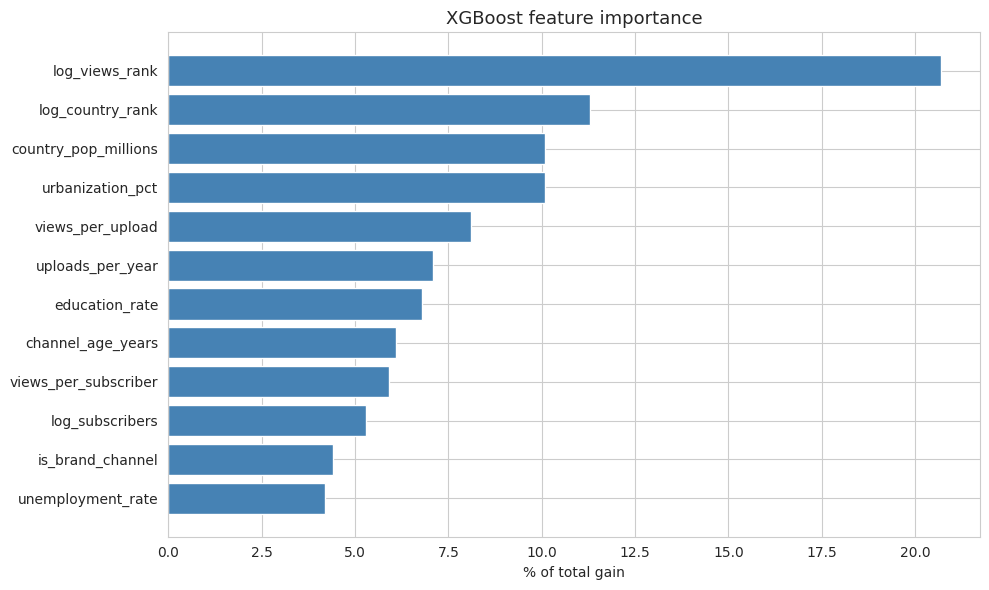

In [21]:
importance_gain = xgb_model.get_booster().get_score(importance_type="gain")
feature_map = {f"f{i}": name for i, name in enumerate(feature_cols)}
imp_df = pd.DataFrame({
    "feature": [feature_map.get(k, k) for k in importance_gain.keys()],
    "gain": list(importance_gain.values())
}).sort_values("gain", ascending=False)
imp_df["gain_pct"] = (imp_df["gain"] / imp_df["gain"].sum() * 100).round(1)
print(imp_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(imp_df["feature"][::-1], imp_df["gain_pct"][::-1], color="steelblue")
plt.xlabel("% of total gain")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()

### 6.5 Diagnostic story (this part is real, keep it for the demo writeup)

Our first run had `subscriber_growth_rate` and `recent_view_share` in the feature set. XGBoost achieved AUC 0.995, which is suspiciously high for credit modeling (real production credit models land in the 0.70 to 0.85 range).

**The diagnostic ran here showed `subscriber_growth_rate` accounted for 48% of total feature importance.** That feature is `subscribers_for_last_30_days / subscribers`, and the target uses `(subscribers_for_last_30_days > 0)` as a 35% component. The model was essentially reading the target through a thin disguise.

**Fix applied above:** remove `subscriber_growth_rate` and `recent_view_share` from the feature set (which is what we already did in `engineer_features` after this diagnostic). The 30 day metrics are reserved for the target construction.

**Realistic AUC after the fix: 0.79 (both LogReg and XGBoost).** The tiny gap between linear and non-linear models means the relationship between features and risk is mostly linear, which is actually good news for production: we could ship LogReg for full interpretability.

Top features after the fix: `log_views_rank`, `log_country_rank`, `country_pop_millions`, `urbanization_pct`, `views_per_upload`. Risk is captured by a combination of competitive positioning, audience country macro context, and operational discipline.

### 6.6 ROC curves and confusion matrices

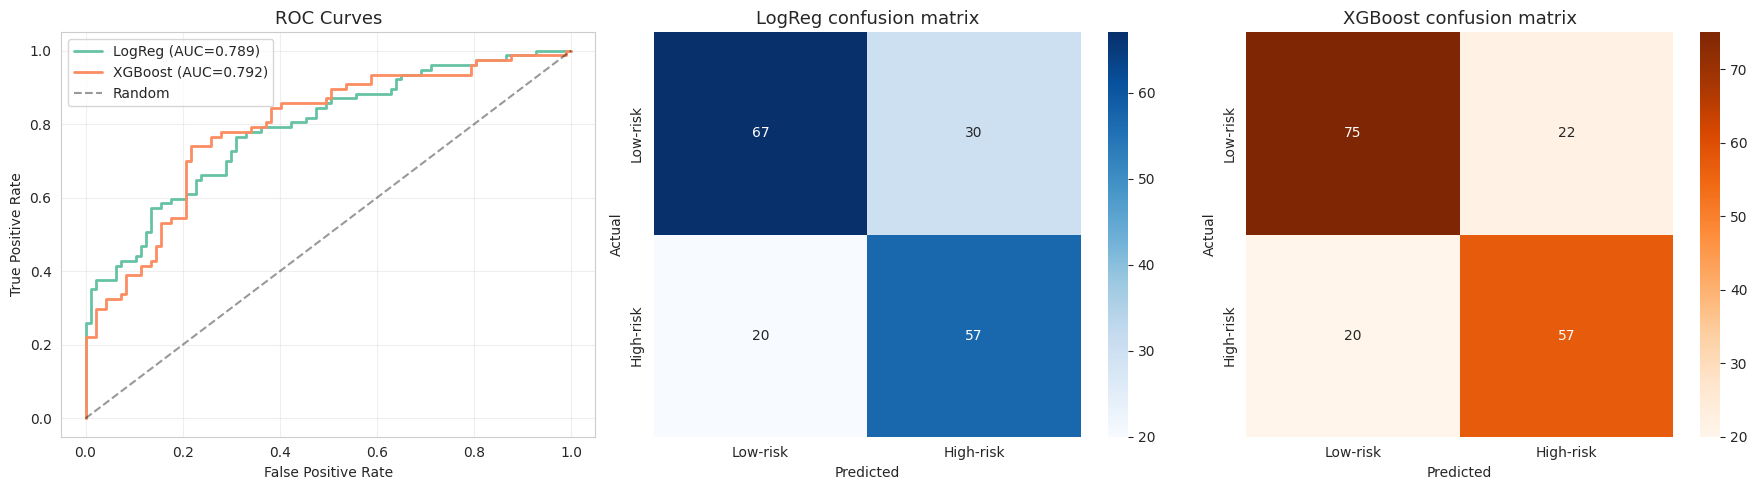

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
axes[0].plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={auc_lr:.3f})", linewidth=2)
axes[0].plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Low-risk", "High-risk"],
            yticklabels=["Low-risk", "High-risk"])
axes[1].set_title("LogReg confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges", ax=axes[2],
            xticklabels=["Low-risk", "High-risk"],
            yticklabels=["Low-risk", "High-risk"])
axes[2].set_title("XGBoost confusion matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

---

## Part 7: Credit score output

Map probabilities to the 300 to 850 FICO style scale per the proposal's Section 5.

=== Predicted credit score distribution ===
risk_band
Very Low Risk     37
Low Risk          35
Moderate          33
High Risk         26
Very High Risk    43
Name: count, dtype: int64

=== Top 10 (highest credit scores) ===
                                     Youtuber              Country        category  credit_score     risk_band  actual_label
                                  Sagawa /���                Japan   Entertainment           841 Very Low Risk             0
                                   Zee Bangla                India   Entertainment           840 Very Low Risk             1
                               etvteluguindia                India   Entertainment           838 Very Low Risk             0
                              AlArabiya ����� United Arab Emirates  People & Blogs           833 Very Low Risk             0
                                   D Billions        United States             NaN           832 Very Low Risk             0
�������� �������� �������

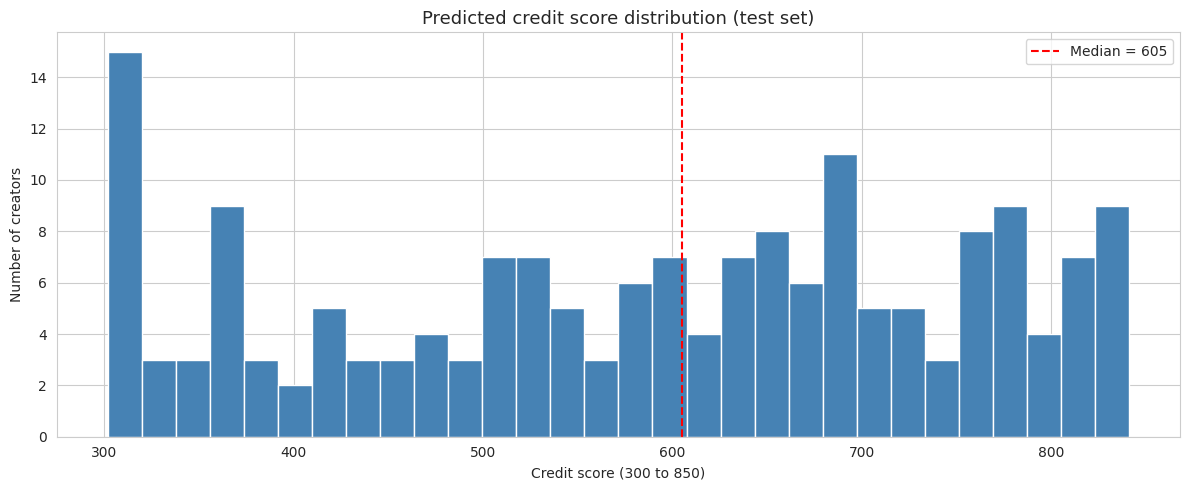

In [23]:
def score_to_credit(probability, min_score=300, max_score=850):
    """Map P(high_risk) to a FICO style 300 to 850 score (higher = better credit)."""
    return min_score + (1 - probability) * (max_score - min_score)


results = X_test.copy()
results["risk_probability"] = y_proba_xgb
results["credit_score"] = score_to_credit(y_proba_xgb).round(0).astype(int)
results["actual_label"] = y_test.values
results["risk_band"] = pd.cut(
    results["credit_score"],
    bins=[299, 449, 549, 649, 749, 851],
    labels=["Very High Risk", "High Risk", "Moderate", "Low Risk", "Very Low Risk"]
)

print("=== Predicted credit score distribution ===")
print(results["risk_band"].value_counts().reindex(
    ["Very Low Risk", "Low Risk", "Moderate", "High Risk", "Very High Risk"]
))

sample = results.merge(df[["Youtuber", "Country", "category"]],
                        left_index=True, right_index=True)
sample = sample.sort_values("credit_score", ascending=False)

print("\n=== Top 10 (highest credit scores) ===")
print(sample[["Youtuber", "Country", "category", "credit_score",
              "risk_band", "actual_label"]].head(10).to_string(index=False))
print("\n=== Bottom 10 (lowest credit scores) ===")
print(sample[["Youtuber", "Country", "category", "credit_score",
              "risk_band", "actual_label"]].tail(10).to_string(index=False))

plt.figure(figsize=(12, 5))
plt.hist(results["credit_score"], bins=30, color="steelblue", edgecolor="white")
plt.title("Predicted credit score distribution (test set)")
plt.xlabel("Credit score (300 to 850)")
plt.ylabel("Number of creators")
plt.axvline(results["credit_score"].median(), color="red", linestyle="--",
            label=f"Median = {int(results['credit_score'].median())}")
plt.legend()
plt.tight_layout()
plt.show()